In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import numba
import jax
import jax.numpy as jnp
from typing import NamedTuple
from functools import partial
import quantecon as qe
from quantecon.distributions import BetaBinomial

n, a, b = 50, 200, 100                        # default parameters
q_default = jnp.array(BetaBinomial(n, a, b).pdf())

w_min, w_max = 10, 60
w_default = jnp.linspace(w_min, w_max, n+1)

fig, ax = plt.subplots()
ax.plot(w_default, q_default, '-o', label='$q(w(i))$')
ax.set_xlabel('wages')
ax.set_ylabel('probabilities')
plt.show()

# We’ll use NamedTuple for our model class to maintain immutability, which works well with JAX’s functional programming paradigm.

class McCallModel(NamedTuple):
    c: float = 25               # unemployment compensation
    β: float = 0.99             # discount factor  
    w: jnp.ndarray = w_default  # array of wage values, w[i] = wage at state i
    q: jnp.ndarray = q_default  # array of probabilities

def T(model: McCallModel, v: jnp.ndarray):
    c, β, w, q = model
    accept = w / (1 - β)
    reject = c + β * v @ q
    return jnp.maximum(accept, reject)

# first guess: v = w / (1 - β)

model = McCallModel()
c, β, w, q = model
v = w / (1 - β)   # Initial condition
fig, ax = plt.subplots()

num_plots = 6
for i in range(num_plots):
    ax.plot(w, v, '-', alpha=0.6, lw=2, label=f"iterate {i}")
    v = T(model, v)

ax.legend(loc='lower right')
ax.set_xlabel('wage')
ax.set_ylabel('value')
plt.show()

In [ ]:
def compute_reservation_wage(
        model: McCallModel,   # instance containing default parameters
        v_init: jnp.ndarray,  # initial condition for iteration
        tol: float=1e-7,      # error tolerance
        max_iter: int=1000,    # maximum number of iterations for loop
    ):
    "Computes the reservation wage in the McCall job search model."
    c, β, w, q = model
    i = 0
    error = tol + 1 
    v = v_init
    
    while i < max_iter and error > tol:
        v_next = T(model, v)
        error = jnp.max(jnp.abs(v_next - v))
        v = v_next
        i += 1
    
    w_bar = (1 - β) * (c + β * v @ q)
    return v, w_bar

model = McCallModel()
c, β, w, q = model
v_init = w / (1 - β)  # initial guess
v, w_bar = compute_reservation_wage(model, v_init)
print(w_bar)

In [ ]:
fig, ax = plt.subplots()

# Get the default color cycle
prop_cycle = plt.rcParams['axes.prop_cycle']
colors = prop_cycle.by_key()['color']

# Plot the wage offer distribution
ax.plot(w, q, '-', alpha=0.6, lw=2,
        label='wage offer distribution',
        color=colors[0])

# Compute reservation wage with default beta
model_default = McCallModel()
c, β, w, q = model_default
v_init = w / (1 - β)
v_default, res_wage_default = compute_reservation_wage(
    model_default, v_init
)

# Compute reservation wage with lower beta
β_new = 0.96
model_low_beta = McCallModel(β=β_new)
c, β_low, w, q = model_low_beta
v_init_low = w / (1 - β_low)
v_low, res_wage_low = compute_reservation_wage(
    model_low_beta, v_init_low
)

# Plot vertical lines for reservation wages
ax.axvline(x=res_wage_default, color=colors[1], lw=2,
           label=f'reservation wage (β={β})')
ax.axvline(x=res_wage_low, color=colors[2], lw=2,
           label=f'reservation wage (β={β_new})')

ax.set_xlabel('wage', fontsize=12)
ax.set_ylabel('probability', fontsize=12)
ax.tick_params(axis='both', which='major', labelsize=11)
ax.legend(loc='upper left', frameon=False, fontsize=11)
plt.show()

In [ ]:
@jax.jit
def compute_res_wage_jitted(
        model: McCallModel,   # instance containing default parameters
        v_init: jnp.ndarray,  # initial condition for iteration
        tol: float=1e-6,      # error tolerance
        max_iter: int=1000,   # maximum number of iterations for loop
    ):
    c, β, w, q = model
    i = 0
    error = tol + 1 
    initial_state = v_init, i, error
    
    def cond(loop_state):
        v, i, error = loop_state
        return jnp.logical_and(i < max_iter, error > tol)

    def update(loop_state):
        v, i, error = loop_state
        v_next = T(model, v)
        error = jnp.max(jnp.abs(v_next - v))
        i += 1
        new_loop_state = v_next, i, error
        return new_loop_state
    
    final_state = jax.lax.while_loop(cond, update, initial_state)
    v, i, error = final_state

    w_bar = (1 - β) * (c + β * v @ q)
    return v, w_bar


grid_size = 25
c_vals = jnp.linspace(10.0, 30.0, grid_size)
β_vals = jnp.linspace(0.9, 0.99, grid_size)

res_wage_matrix = np.empty((grid_size, grid_size))
model = McCallModel()
v_init = model.w / (1 - model.β)

for i, c in enumerate(c_vals):
    for j, β in enumerate(β_vals):
        model = McCallModel(c=c, β=β)
        v, w_bar = compute_res_wage_jitted(model, v_init)
        v_init = v
        res_wage_matrix[i, j] = w_bar

fig, ax = plt.subplots()
cs1 = ax.contourf(c_vals, β_vals, res_wage_matrix.T, alpha=0.75, levels=15)
ctr1 = ax.contour(c_vals, β_vals, res_wage_matrix.T, levels=15)
plt.clabel(ctr1, inline=1, fontsize=13)
plt.colorbar(cs1, ax=ax)
ax.set_title("reservation wage")
ax.set_xlabel("$c$", fontsize=16)
ax.set_ylabel("$β$", fontsize=16)
ax.ticklabel_format(useOffset=False)
plt.show()

In [ ]:
class McCallModel(NamedTuple):
    c: float = 25               # unemployment compensation
    β: float = 0.99             # discount factor  
    w: jnp.ndarray = w_default  # array of wage values, w[i] = wage at state i
    q: jnp.ndarray = q_default  # array of probabilities

def compute_reservation_wage_two(
        model: McCallModel,   # instance containing default parameters
        tol: float=1e-5,      # error tolerance
        max_iter: int=500,    # maximum number of iterations for loop
    ):
    c, β, w, q = model
    h_init = (w @ q) / (1 - β)
    i=0
    error = tol + 1
    initial_state = h_init, i, error

    def cond(loop_state):
        h, i, error = loop_state
        return jnp.logical_and(i<max_iter, error>tol)

    def update(loop_state):
        h, i, error = loop_state

        s = jnp.maximum(w/(1-β), h)
        h_next = c + β * s @ q

        error = jnp.abs(h - h_next)
        i = i + 1

        next_loop_state = h_next, i, error
        return next_loop_state
    
    final_state = jax.lax.while_loop(cond, update, initial_state)
    h, i, error = final_state

    return (1 - β) * h


$$h = c + \beta \sum_{w' \in \mathbb{W}} \max \left\{ \frac{w'}{1 - \beta}, h \right\} q(w')$$
$$h = c + \beta \int v^*(s') q(s') ds'$$
$$h = c + \beta \int \max \left\{ \frac{w(s')}{1 - \beta}, h \right\} q(s') ds'$$

In [ ]:
class McCallModelContinuous(NamedTuple):
    c: float              # unemployment compensation
    β: float              # discount factor
    σ: float              # scale parameter in lognormal distribution
    μ: float              # location parameter in lognormal distribution
    w_draws: jnp.ndarray  # draws of wages for Monte Carlo


def create_mccall_continuous(
        c=25, β=0.99, σ=0.5, μ=2.5, mc_size=1000, seed=1234
    ):
    key = jax.random.PRNGKey(seed)
    s = jax.random.normal(key, (mc_size,))
    w_draws = jnp.exp(μ + σ * s)
    return McCallModelContinuous(c, β, σ, μ, w_draws)


@jax.jit
def compute_reservation_wage_continuous(model, max_iter=500, tol=1e-5):
    c, β, σ, μ, w_draws = model

    h = jnp.mean(w_draws) / (1 - β)  # initial guess

    def update(state):
        h, i, error = state
        integral = jnp.mean(jnp.maximum(w_draws / (1 - β), h))
        h_next = c + β * integral
        error = jnp.abs(h_next - h)
        return h_next, i + 1, error

    def cond(state):
        h, i, error = state
        return jnp.logical_and(i < max_iter, error > tol)

    initial_state = (h, 0, tol + 1)
    final_state = jax.lax.while_loop(cond, update, initial_state)
    h_final, _, _ = final_state

    # Now compute the reservation wage
    return (1 - β) * h_final


grid_size = 25
c_vals = jnp.linspace(10.0, 30.0, grid_size)
β_vals = jnp.linspace(0.9, 0.99, grid_size)

def compute_R_element(c, β):
    model = create_mccall_continuous(c=c, β=β)
    return compute_reservation_wage_continuous(model)

# First, vectorize over β (holding c fixed)
compute_R_over_β = jax.vmap(compute_R_element, in_axes=(None, 0))

# Next, vectorize over c (applying the above function to each c)
compute_R_vectorized = jax.vmap(compute_R_over_β, in_axes=(0, None))

# Apply to compute the full grid
R = compute_R_vectorized(c_vals, β_vals)



In [ ]:
fig, ax = plt.subplots()
cs1 = ax.contourf(c_vals, β_vals, R.T, alpha=0.75, levels=15)
ctr1 = ax.contour(c_vals, β_vals, R.T, levels=15)
plt.clabel(ctr1, inline=1, fontsize=13)
plt.colorbar(cs1, ax=ax)
ax.set_title("reservation wage")
ax.set_xlabel("$c$", fontsize=16)
ax.set_ylabel("$β$", fontsize=16)
ax.ticklabel_format(useOffset=False)
plt.show()

In [ ]:
@jax.jit
def compute_reservation_wage_continuous(model, max_iter=500, tol=1e-5):
    c, β, σ, μ, w_draws = model

    h = jnp.mean(w_draws) / (1 - β)  # initial guess

    def update(state):
        h, i, error = state
        integral = jnp.mean(jnp.maximum(w_draws / (1 - β), h))
        h_next = c + β * integral
        error = jnp.abs(h_next - h)
        return h_next, i + 1, error

    def cond(state):
        h, i, error = state
        return jnp.logical_and(i < max_iter, error > tol)

    initial_state = (h, 0, tol + 1)
    final_state = jax.lax.while_loop(cond, update, initial_state)
    h_final, _, _ = final_state

    # Now compute the reservation wage
    return (1 - β) * h_final


@jax.jit
def simulate_lifetime_value(key, model, w_bar, n_periods=100):
    """
    Simulate one realization of the wage path and compute lifetime value.

    Parameters:
    -----------
    key : jax.random.PRNGKey
        Random key for JAX
    model : McCallModelContinuous
        The model containing parameters
    w_bar : float
        The reservation wage
    n_periods : int
        Number of periods to simulate

    Returns:
    --------
    lifetime_value : float
        Discounted sum of income over n_periods
    """
    c, β, σ, μ, w_draws = model

    # Draw all wage offers upfront
    key, subkey = jax.random.split(key)
    s_vals = jax.random.normal(subkey, (n_periods,))
    wage_offers = jnp.exp(μ + σ * s_vals)

    # Determine which offers are acceptable
    accept = wage_offers >= w_bar

    # Track employment status: employed from first acceptance onward
    employed = jnp.cumsum(accept) > 0

    # Get the accepted wage (first wage where accept is True)
    first_accept_idx = jnp.argmax(accept)
    accepted_wage = wage_offers[first_accept_idx]

    # Earnings at each period: accepted_wage if employed, c if unemployed
    earnings = jnp.where(employed, accepted_wage, c)

    # Compute discounted sum
    periods = jnp.arange(n_periods)
    discount_factors = β ** periods
    lifetime_value = jnp.sum(discount_factors * earnings)

    return lifetime_value


@jax.jit
def compute_mean_lifetime_value(model, w_bar, num_reps=10000, seed=1234):
    """
    Compute mean lifetime value across many simulations.

    """
    key = jax.random.PRNGKey(seed)
    keys = jax.random.split(key, num_reps)

    # Vectorize the simulation across all replications
    simulate_fn = jax.vmap(simulate_lifetime_value, in_axes=(0, None, None))
    lifetime_values = simulate_fn(keys, model, w_bar)
    return jnp.mean(lifetime_values)


# Use the same volatility range and mean wage
σ_vals = jnp.linspace(0.1, 1.0, 25)
mean_wage = 20.0


class McCallModelContinuous(NamedTuple):
    c: float              # unemployment compensation
    β: float              # discount factor
    σ: float              # scale parameter in lognormal distribution
    μ: float              # location parameter in lognormal distribution
    w_draws: jnp.ndarray  # draws of wages for Monte Carlo

def create_mccall_continuous(
        c=25, β=0.99, σ=0.5, μ=2.5, mc_size=1000, seed=1234
    ):
    key = jax.random.PRNGKey(seed)
    s = jax.random.normal(key, (mc_size,))
    w_draws = jnp.exp(μ + σ * s)
    return McCallModelContinuous(c, β, σ, μ, w_draws)

# Given σ, compute μ to maintain constant mean
def compute_μ_for_mean(σ, mean_wage):
    return jnp.log(mean_wage) - (σ**2) / 2

lifetime_vals = []
for σ in σ_vals:
    μ = compute_μ_for_mean(σ, mean_wage)
    model = create_mccall_continuous(σ=σ, μ=μ)
    w_bar = compute_reservation_wage_continuous(model)
    lv = compute_mean_lifetime_value(model, w_bar)
    lifetime_vals.append(lv)

fig, ax = plt.subplots()
ax.plot(σ_vals, lifetime_vals, linewidth=2, color='green')
ax.set_xlabel(r'volatility ($\sigma$)', fontsize=12)
ax.set_ylabel('expected lifetime value', fontsize=12)
plt.show()

### Exercise

Compute the average duration of unemployment when $\beta = 0.99$ and $c$ takes the following values

```python
c_vals = np.linspace(10, 40, 4)
```

That is, start the agent off as unemployed, compute their reservation wage given the parameters, and then simulate to see how long it takes to accept.

Repeat a large number of times and take the average.

Plot mean unemployment duration as a function of `c` in `c_vals`.

Try to explain what you see.

In [ ]:
# Exercise

import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import numpy as np
from typing import NamedTuple

test_period = 100000
sample_size = 1000

# build Mccall model class
class mcmodel(NamedTuple):
    # default values
    c:float = 25 
    β:float = 0.99
    σ:float = 0.5
    μ:float = 2.5
    mc_size:float = 1000
    seed:int = 1234

# select the wage set
def selectwageset(model:mcmodel):
    c, β, σ, μ, mc_size, seed = model
    key = jax.random.key(seed)
    key, subkey = jax.random.split(key)
    subkeys = jax.random.split(subkey, sample_size)
    s = jax.random.normal(key, (mc_size,))
    w = jnp.exp(μ + σ*s)
    return (w, subkeys)

# calculate reservation wage
@jax.jit
def calculate_reser_wage(model:mcmodel, w:jnp.ndarray, 
                         tol:float = 1e-6, maxitertime:int = 1000):
    c, β, σ, μ, mc_size, seed = model

    h_init = jnp.mean(w/(1-β))
    error = tol+1
    i = 0

    init_state = (h_init, error, i)

    def cond(loop_state):
        h, error, i = loop_state
        return jnp.logical_and(error>tol, i<maxitertime)
    
    def update(loop_state):
        h, error, i = loop_state
        integral = jnp.mean(jnp.maximum(w/(1-β),h))
        h_next = β * integral + c

        error = jnp.abs(h_next - h)
        i = i+1

        next_state = h_next, error, i
        return next_state

    final_state = jax.lax.while_loop(cond, update, init_state)
    h, _, _ = final_state
    res_w = h * (1 - β)
    return res_w

# calculate the number of unemployment periods

def unemploy_length(model, res_w, subkey, T = test_period):
    c, β, σ, μ, mc_size, seed = model

    life = list()

    for key in subkey:
        s = jax.random.normal(key, (T,))
        w = jnp.exp(μ + σ*s)
        accept = w >= res_w
        unem_period = jnp.argmax(accept)
        life.append(unem_period)

    return jnp.mean(life)


c_vals = np.linspace(10, 40, 4)
length_vals = list()

for c in c_vals:
    model = mcmodel(c=c)
    w, subkey = selectwageset(model)
    res_w = calculate_reser_wage(model, w)
    length = unemploy_length(model,res_w, subkey)
    length_vals.append(length)

fig, ax = plt.subplots()
ax.plot(c_vals, length_vals)
plt.show()




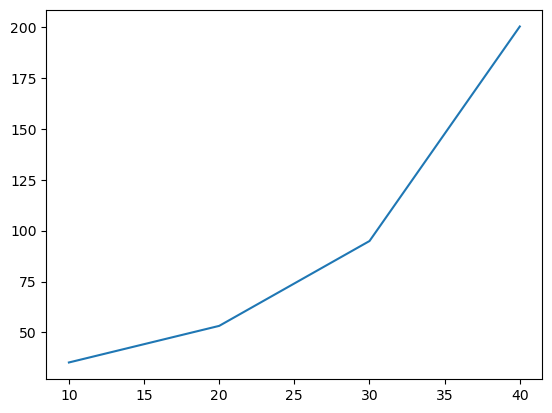

In [5]:
# Improve 1

import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import numpy as np
from typing import NamedTuple

test_period = 100000
sample_size = 10000

# build Mccall model class
class mcmodel(NamedTuple):
    # default values
    c:float = 25 
    β:float = 0.99
    σ:float = 0.5
    μ:float = 2.5
    mc_size:int = 1000
    seed:int = 1234

# select the wage set
def selectwageset(model:mcmodel,key):
    c, β, σ, μ, mc_size, seed = model
    s = jax.random.normal(key, (mc_size,))
    w = jnp.exp(μ + σ*s)
    return w

# calculate reservation wage
@jax.jit
def calculate_reser_wage(model:mcmodel, w:jnp.ndarray, 
                         tol:float = 1e-6, maxitertime:int = 1000):
    c, β, σ, μ, mc_size, seed = model

    h_init = jnp.mean(w/(1-β))
    error = tol+1
    i = 0

    init_state = (h_init, error, i)

    def cond(loop_state):
        h, error, i = loop_state
        return jnp.logical_and(error>tol, i<maxitertime)
    
    def update(loop_state):
        h, error, i = loop_state
        integral = jnp.mean(jnp.maximum(w/(1-β),h))
        h_next = β * integral + c

        error = jnp.abs(h_next - h)
        i = i+1

        next_state = h_next, error, i
        return next_state

    final_state = jax.lax.while_loop(cond, update, init_state)
    h, _, _ = final_state
    res_w = h * (1 - β)
    return res_w

# calculate the number of unemployment periods

@jax.jit
def single_unemploy_length(key, model, res_w, T=test_period):
    c, β, σ, μ, mc_size, seed = model

    s = jax.random.normal(key, (T,))
    w = jnp.exp(μ + σ*s)
    accept = w >= res_w

    return jnp.argmax(accept)

@jax.jit
def unemploy_length(model, res_w, keys, seed=1234):
    simulate_fn = jax.vmap(single_unemploy_length, in_axes=(0, None, None))
    periods = simulate_fn(keys, model, res_w)
    return jnp.mean(periods)

@jax.jit
def final_function(c):
    model = mcmodel(c=c)

    key = jax.random.key(model.seed)
    key1, key2 = jax.random.split(key)
    w = selectwageset(model, key1)
    keys = jax.random.split(key2, sample_size)

    res_w = calculate_reser_wage(model, w)
    length = unemploy_length(model, res_w, keys)
    return length


c_vals = np.linspace(10, 40, 4)
final_function_vectorized = jax.vmap(final_function)
length_vals = final_function_vectorized(c_vals)


fig, ax = plt.subplots()
ax.plot(c_vals, length_vals)
plt.show()




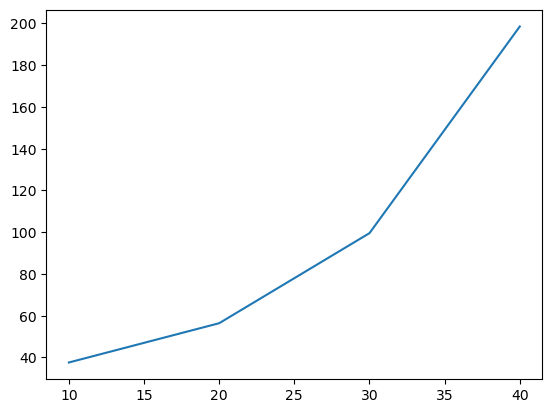

In [10]:
# Improve 2

import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt
import numpy as np
from typing import NamedTuple

# build Mccall model class
class mcmodel(NamedTuple):
    # default values
    c:float
    β:float
    σ:float
    μ:float
    w_draws: jnp.ndarray

def create_mcmodel(
        c=25, β=0.99, σ=0.5, μ=2.5, mc_size=1000, seed=1234
    ):
    key = jax.random.key(seed)
    s = jax.random.normal(key,(mc_size,))
    w_draws = jnp.exp(s * σ + μ)
    return mcmodel(c,β,σ,μ,w_draws)

# calculate reservation wage
def calculate_reser_wage(model:mcmodel, 
                         tol:float = 1e-6, maxitertime:int = 1000):
    c, β, _, _, w_draws = model

    h_init = jnp.mean(w_draws/(1-β))
    error = tol+1
    i = 0

    init_state = (h_init, error, i)

    def cond(loop_state):
        _, error, i = loop_state
        return jnp.logical_and(error>tol, i<maxitertime)
    
    def update(loop_state):
        h, error, i = loop_state
        integral = jnp.mean(jnp.maximum(w_draws/(1-β),h))
        h_next = β * integral + c

        error = jnp.abs(h_next - h)
        i = i+1

        next_state = h_next, error, i
        return next_state

    final_state = jax.lax.while_loop(cond, update, init_state)
    h, _, _ = final_state
    res_w = h * (1 - β)
    return res_w

# calculte number of umemployment periods
def single_unemploy_length(key,model,w_bar):

    _, _, σ, μ, _ = model

    t = 1
    s = jax.random.normal(key)
    w = jnp.exp(s*σ+μ)
    init_state = (t, key, w)

    def cond(loop_state):
        _, _, w = loop_state
        return jnp.logical_not(w>w_bar)

    def update(loop_state):
        t, key, w = loop_state
        t = t+1

        key, subkey = jax.random.split(key)
        s = jax.random.normal(subkey)
        w = jnp.exp(μ + σ*s)

        next_state = (t, key, w)
        return next_state

    final_t,_,_ = jax.lax.while_loop(cond,update,init_state)

    return final_t

# calculate mean unemployment length 
def mean_unemploy_length(model, w_bar, seed = 2345, simu_time = 100000):
    key = jax.random.key(seed)
    subkeys = jax.random.split(key,simu_time)
    single_unemploy_length_vector = jax.vmap(single_unemploy_length, in_axes=(0,None,None))
    return jnp.mean(single_unemploy_length_vector(subkeys, model, w_bar))

# simulate function for each c
@jax.jit
def simulate_c(c):
    model = create_mcmodel(c=c)
    w_bar = calculate_reser_wage(model)
    return mean_unemploy_length(model, w_bar)

c_vals = np.linspace(10, 40, 4)
simulate_c_vector = jax.vmap(simulate_c,in_axes=(0))
unemploy_length_vals = simulate_c_vector(c_vals)


fig, ax = plt.subplots()
ax.plot(c_vals, unemploy_length_vals)
plt.show()




In [12]:
# 解析解
from scipy.stats import norm

c_vals = np.linspace(10, 40, 4)

for c in c_vals:
    model = create_mcmodel(c=c)
    w_bar = calculate_reser_wage(model)
    p_accept = 1 - norm.cdf((jnp.log(w_bar) - model.μ) / model.σ)
    analytical_duration = 1 / p_accept
    print(analytical_duration)

37.586716702812225
56.3430750200632
99.78546991275067
199.82920341841643
